In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    Parameters:
        z (numpy.ndarray): Logits of shape (m, n)
    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n)
    """
    # Subtract row-wise max for numerical stability (prevents exp overflow)
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Test Case
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")
print("Softmax output:\n", softmax_output)

Softmax function passed the test case!
Softmax output:
 [[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]


In [3]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model.
    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d)
        W (numpy.ndarray): Weight matrix of shape (d, c)
        b (numpy.ndarray): Bias vector of shape (c,)
    Returns:
        numpy.ndarray: Predicted class labels of shape (n,)
    """
    z = np.dot(X, W) + b          # logits: shape (n, c)
    probs = softmax(z)             # probabilities: shape (n, c)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes


#  Test Case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


In [4]:
def loss_softmax(y_pred, y):
    """
    Compute the categorical cross-entropy loss.
    Works for single sample (c,) or batch (n, c).
    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities
        y      (numpy.ndarray): True labels (one-hot encoded)
    Returns:
        float: Average cross-entropy loss
    """
    # Clip to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=-1))
    return loss

# ── Test Case
y_true_correct   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct   = np.array([[0.9, 0.05, 0.05],
                              [0.1, 0.85, 0.05],
                              [0.05, 0.1,  0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1,  0.05, 0.85],
                              [0.85, 0.1,  0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


In [5]:
def cost_softmax(X, y, W, b):
    """
    Compute the average cross-entropy loss over all samples.
    Parameters:
        X (numpy.ndarray): Feature matrix (n, d)
        y (numpy.ndarray): True labels one-hot encoded (n, c)
        W (numpy.ndarray): Weights (d, c)
        b (numpy.ndarray): Bias (c,)
    Returns:
        float: Average cross-entropy cost
    """
    n = X.shape[0]
    z = np.dot(X, W) + b               # (n, c)
    y_pred = softmax(z)                 # (n, c)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(y_pred_clipped))
    return total_loss / n


# Test Case
X_correct   = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct   = np.array([[1, 0], [0, 1]])
W_correct   = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct   = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)
print(f"Cost for correct prediction:   {cost_correct:.4f}")
print(f"Cost for incorrect prediction: {cost_incorrect:.4f}")
print("Test passed!")

Cost for correct prediction:   0.0006
Cost for incorrect prediction: 0.2993
Test passed!


In [6]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of the cost w.r.t. weights and biases.
    Parameters:
        X (numpy.ndarray): Feature matrix (n, d)
        y (numpy.ndarray): True labels one-hot (n, c)
        W (numpy.ndarray): Weights (d, c)
        b (numpy.ndarray): Bias (c,)
    Returns:
        tuple: (grad_W of shape (d, c), grad_b of shape (c,))
    """
    n = X.shape[0]
    z      = np.dot(X, W) + b    # (n, c)
    y_pred = softmax(z)           # (n, c)

    error  = y_pred - y           # (n, c)

    grad_W = np.dot(X.T, error) / n   # (d, c)
    grad_b = np.sum(error, axis=0) / n # (c,)
    return grad_W, grad_b


# Test Case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test        = np.dot(X_test, W_test) + b_test
y_pred_test   = softmax(z_test)
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), f"Test failed: grad_W mismatch"
assert np.allclose(grad_b, grad_b_manual), f"Test failed: grad_b mismatch"
print("Gradient w.r.t. W:\n", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W:
 [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [7]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Gradient descent optimizer for softmax regression.
    Parameters:
        X        (numpy.ndarray): Feature matrix (n, d)
        y        (numpy.ndarray): True labels one-hot (n, c)
        W        (numpy.ndarray): Weights (d, c)
        b        (numpy.ndarray): Bias (c,)
        alpha    (float): Learning rate
        n_iter   (int):   Number of iterations
        show_cost (bool): Print cost every 100 iterations
    Returns:
        tuple: (W_optimized, b_optimized, cost_history)
    """
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Record cost
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # Print every 100 iterations
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i:>4d} | Cost: {current_cost:.6f}")

    return W, b, cost_history

In [8]:
# Download MNIST CSV automatically
import os

CSV_PATH = "mnist_train.csv"

if not os.path.exists(CSV_PATH):
    print("Fetching MNIST from sklearn (first time only)...")
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X_raw = mnist.data.astype(np.uint8)
    y_raw = mnist.target.astype(int)
    df_mnist = pd.DataFrame(X_raw)
    df_mnist.insert(0, "label", y_raw)
    df_mnist.to_csv(CSV_PATH, index=False)
    print(f"Saved to {CSV_PATH}")
else:
    print(f"Found: {CSV_PATH}")

Fetching MNIST from sklearn (first time only)...
Saved to mnist_train.csv


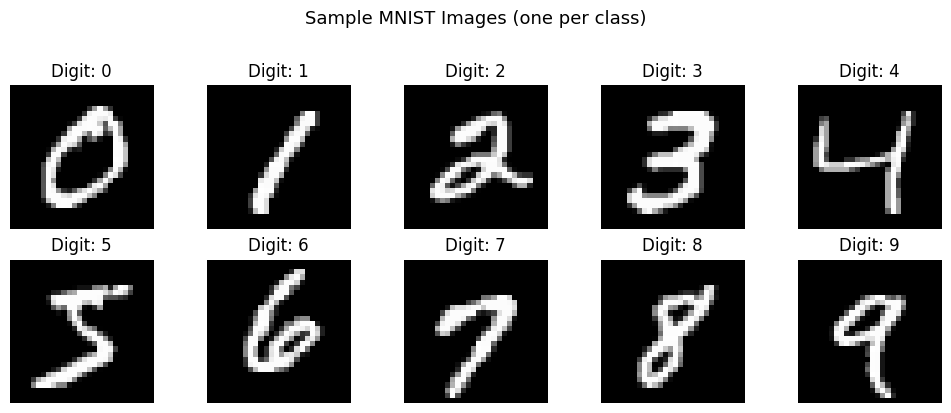

Train: (56000, 784) | Test: (14000, 784)


In [9]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Digit: {digit}")
        plt.axis("off")
    plt.suptitle("Sample MNIST Images (one per class)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df  = pd.read_csv(csv_file)
    y   = df.iloc[:, 0].values       # first column = label
    X   = df.iloc[:, 1:].values      # remaining = pixels
    X   = X / 255.0                  # normalize to [0, 1]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    plot_sample_images(X, y)
    print(f"Train: {X_train.shape} | Test: {X_test.shape}")
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_and_prepare_mnist(CSV_PATH)

Dimensions matched - ready to train.
y_train: (56000, 10) | y_test: (14000, 10)
Iteration    0 | Cost: 2.201282
Iteration  100 | Cost: 0.603895
Iteration  200 | Cost: 0.486033
Iteration  300 | Cost: 0.437370
Iteration  400 | Cost: 0.409272
Iteration  500 | Cost: 0.390409
Iteration  600 | Cost: 0.376606
Iteration  700 | Cost: 0.365926
Iteration  800 | Cost: 0.357334
Iteration  900 | Cost: 0.350220
Iteration  999 | Cost: 0.344255


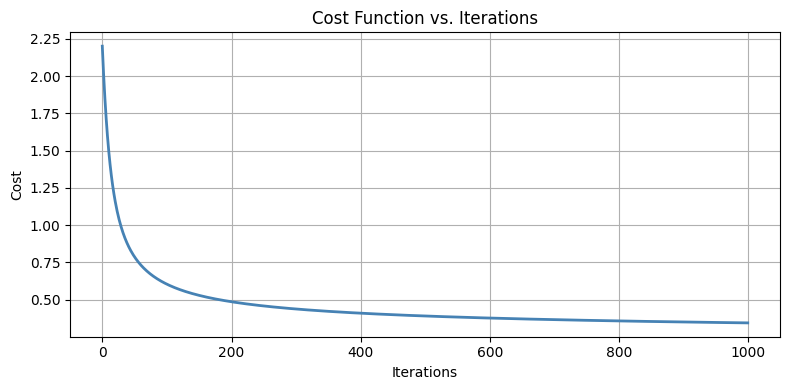

In [11]:
# Shape check
assert len(X_train) == len(y_train), "Shape mismatch!"
print("Dimensions matched - ready to train.")

# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

# Initialize weights
d = X_train.shape[1]           # 784 features
c = y_train.shape[1]           # 10 classes

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha  = 0.1
n_iter = 1000

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot cost
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="steelblue", linewidth=2)
plt.title("Cost Function vs. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.tight_layout()
plt.show()


Confusion Matrix:
[[1294    0    4    2    1   12   16    1   11    2]
 [   0 1548    3   12    1    9    1    6   17    3]
 [   5   20 1203   19   27    6   31   25   37    7]
 [   3    8   29 1266    0   54   14   16   25   18]
 [   2    5   12    2 1183    0   12    5    8   66]
 [  13   15    8   61   22 1070   16    6   47   15]
 [   4    4   18    4   16   22 1318    1    8    1]
 [  10   19   25    5   13    3    0 1382    3   43]
 [   8   35   18   54    9   36   17   11 1148   21]
 [  10   10    9   16   49   10    0   47   13 1256]]
Precision : 0.90
Recall    : 0.90
F1-Score  : 0.90


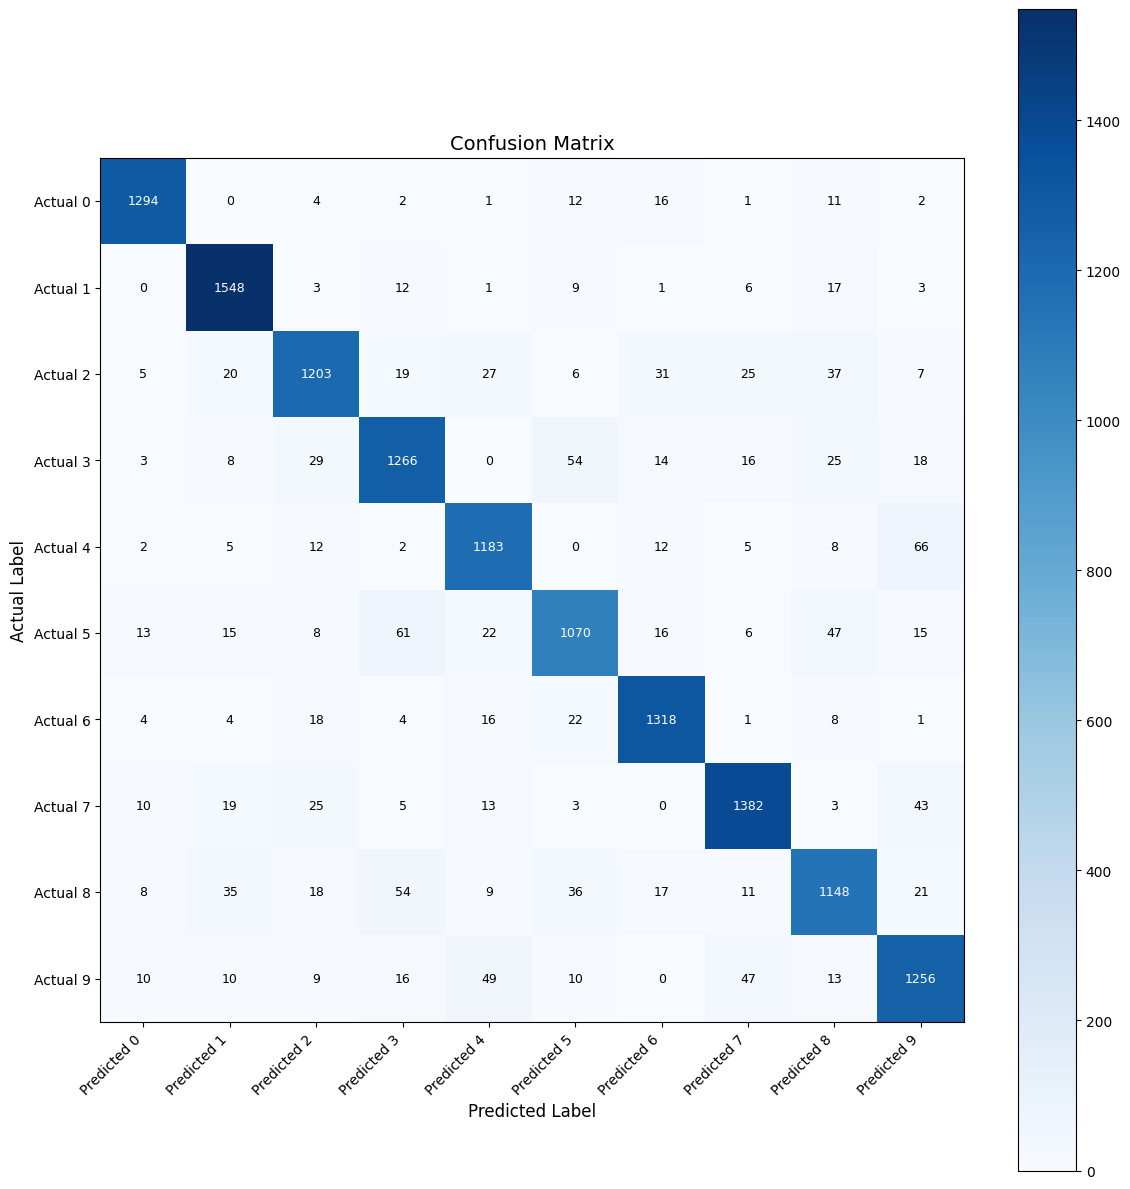

In [12]:
def evaluate_classification(y_true, y_pred):
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall    = recall_score(y_true, y_pred,    average="weighted")
    f1        = f1_score(y_true, y_pred,        average="weighted")
    return cm, precision, recall, f1


# Predict
y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap="Blues")

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f"Predicted {i}" for i in range(num_classes)], rotation=45, ha="right")
ax.set_yticklabels([f"Actual {i}"    for i in range(num_classes)])

threshold = np.max(cm) / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                color="white" if cm[i, j] > threshold else "black")

ax.grid(False)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

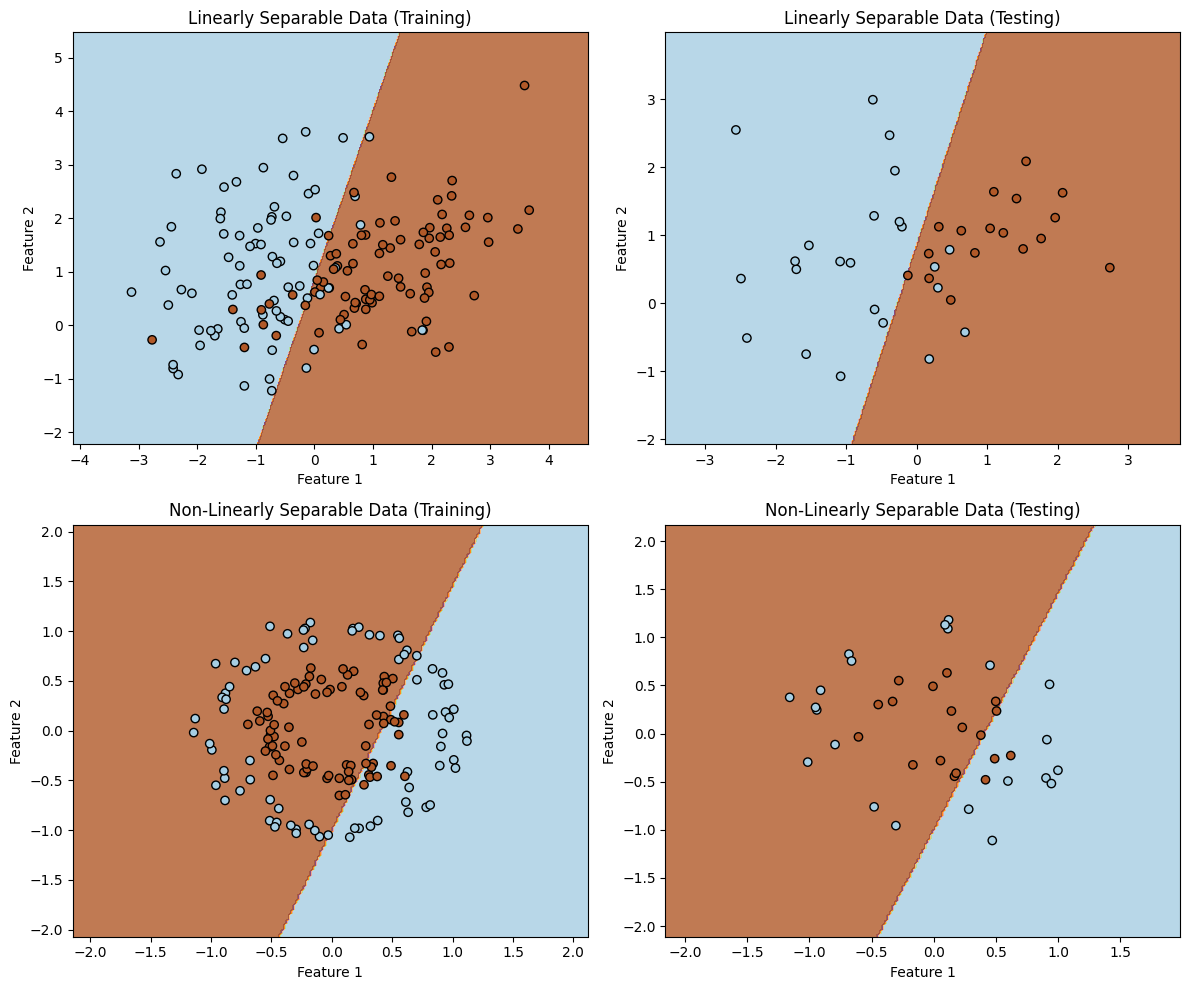

In [13]:
np.random.seed(42)

# Linearly separable data
X_lin, y_lin = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)
model_lin = LogisticRegression()
model_lin.fit(X_train_lin, y_train_lin)

# Non-linearly separable data (circles)
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
X_train_circ, X_test_circ, y_train_circ, y_test_circ = train_test_split(
    X_circ, y_circ, test_size=0.2, random_state=42
)
model_circ = LogisticRegression()
model_circ.fit(X_train_circ, y_train_circ)


def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(axes[0, 0], model_lin,  X_train_lin,  y_train_lin,  "Linearly Separable Data (Training)")
plot_decision_boundary(axes[0, 1], model_lin,  X_test_lin,   y_test_lin,   "Linearly Separable Data (Testing)")
plot_decision_boundary(axes[1, 0], model_circ, X_train_circ, y_train_circ, "Non-Linearly Separable Data (Training)")
plot_decision_boundary(axes[1, 1], model_circ, X_test_circ,  y_test_circ,  "Non-Linearly Separable Data (Testing)")

plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=150)
plt.show()

Ques 1
Raw pixel values are a reasonable baseline but not ideal. They carry spatial redundancy and are sensitive to lighting and rotation. For a clean, centred dataset like MNIST a linear model can still reach ~90% accuracy, but richer features (edges, gradients, convolutional representations) would be needed for harder real-world data. Normalising pixels to [0, 1] at minimum improves convergence.

Ques 2
The top row (linearly separable) shows a clean straight-line boundary that separates both classes well on training and test data — Logistic Regression is a natural fit here. The bottom row (circles) shows the same straight-line boundary failing badly; because the true boundary is circular, a linear classifier cannot capture it, leading to heavy misclassification on both sets.

Ques 3
Challenges faced

Numerical overflow in softmax — solved by subtracting the row-wise maximum before exp().
log(0) in cross-entropy — solved by clipping predictions to [1e-15, 1-1e-15].
Shape tracking — keeping (n,d), (d,c), (n,c), (c,) consistent across every function requires careful use of axis and keepdims.
Training time — 784 features × 60 000 samples makes each gradient step slow on CPU; reducing iterations or using a data subset speeds up prototyping.